## Projekt analityczny - Statystyczne Reguły Decyzyjne

In [1]:
# IMPORTOWANIE BIBLIOTEK
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import missingno as msno
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,roc_auc_score, roc_curve, f1_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score
from ucimlrepo import fetch_ucirepo

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo

In [4]:
# IMPORT I WCZYTANIE DANYCH 

# Fetch dataset
adult = fetch_ucirepo(id=2)

# Dane jako pandas DataFrames
X1 = adult.data.features
y1 = adult.data.targets

# Połączenie features and target w jeden DataFrame
df = pd.concat([X1, y1], axis=1)

# CSV
df.to_csv("adult_dataset.csv", index=False)

print(adult.metadata)
print(adult.variables)

# Wczytanie 
df = pd.read_csv("adult_dataset.csv")

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

# 1. Wprowadzanie i opis wybranego problemu (klasyfikacja lub regresja), opis zbioru danych.

##### Zbiór danych wkorzystany w analizie to zbiór _Adult_ będący ekstrakcją dokonaną przez Barry'ego Beckera z bazy danych Census z roku 1994
##### Celem analizy jest klasyfikacja czy dochód osoby przekracza $50 000 w ciągu roku

Zbiór danych zawiera następujące zmienne:
- **age**: wiek jednostki - _zmienna ciągła, przyjmująca dodatnie wartości całkowite_
- **workclass**: status zatrudnienia jednostki - _zmienna kategoryczna, przyjmująca 10 poziomów_
- **fnlwgt** (final weight): finalna waga rekordu, interpretowana jako liczbę osób reprezentowaną przez dany wiersz - _zmienna ciągła, przyjmująca dodatnie wartości całkowite_
- **education**: poziom edukacji - _zmienna kategoryczna, przyjmująca 16 poziomów_
- **education-num**: poziom edukacji w kategoriach reprezentowanych jako wartości całkowitoliczbowe - _zmienna kategoryczna, przyjmująca 13 poziomów_
- **marital-status**: stan cywilny osoby - _zmienna kategoryczna, przyjmująca 7 poziomów_
- **occupation**: przybliżony rodzaj zawodu - _zmienna kategoryczna, przyjmująca 16 poziomów_
- **relationship**: relacja w kontekście rodziny - _zmienna kategoryczna, przyjmująca 6 poziomów_
- **race**: rasa osoby - _zmienna kategoryczna, przyjmująca 5 poziomów_
- **sex**: płeć osoby - _zmienna zero-jedynkowa_
- **capital-gain**: przyrost kapitału w dolarach - _zmienna ciągła_
- **capital-loss**: utrata kapitału w dolarach - _zmienna ciągła_
- **hours-per-week**: godziny pracy w tygodniu - _zmienna ciągła, przyjmująca dodatnie wartości całkowite_
- **native-country**: kraj urodzenia - _zmienna kategoryczna, przyjmująca 43 poziomy_
- **income**: zmienna celu, 1 dla dochodu > 50 000, 0 w przeciwnym przypadku (dochód <= 50 000)
  
_Żródło: https://minds.wisconsin.edu/bitstream/handle/1793/82299/TR1869%20Junda%20Chen%203.pdf?sequence=1&isAllowed=y_

# 2. Czyszczenie i wstępne przetwarzanie danych - imputacja braków danych, standaryzacja, kodowanie typu one-hot, transformacja wartości odstających, itp.

In [5]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
#typy zmiennych i braki danych (workclass, occupation, native-country)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


In [7]:
# Wybranie tylko kolumn kategorycznych (object i category)
# Problem:
# - wartości puste
# - wartości oznaczone jako '?' dla zmiennych workclass, occupation, native-country
# - zmienna income ma wartości z kropką
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Znaleziono {len(cat_cols)} zmiennych kategorycznych:\n")

for col in cat_cols:
    unique_values = df[col].unique()
    print(f"--- Kolumna: {col} ---")
    print(f"Liczba kategorii: {len(unique_values)}")
    print(f"Wartości: {unique_values}")
    print("-" * 30)

Znaleziono 9 zmiennych kategorycznych:

--- Kolumna: workclass ---
Liczba kategorii: 10
Wartości: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' nan]
------------------------------
--- Kolumna: education ---
Liczba kategorii: 16
Wartości: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
------------------------------
--- Kolumna: marital-status ---
Liczba kategorii: 7
Wartości: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
------------------------------
--- Kolumna: occupation ---
Liczba kategorii: 16
Wartości: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces

In [8]:
# Oznaczenie obserwacji z '?' jako nulle
df.replace('?', np.nan, inplace=True)

In [9]:
# OK
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Znaleziono {len(cat_cols)} zmiennych kategorycznych:\n")

for col in cat_cols:
    unique_values = df[col].unique()
    print(f"--- Kolumna: {col} ---")
    print(f"Liczba kategorii: {len(unique_values)}")
    print(f"Wartości: {unique_values}")
    print("-" * 30)

Znaleziono 9 zmiennych kategorycznych:

--- Kolumna: workclass ---
Liczba kategorii: 9
Wartości: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
------------------------------
--- Kolumna: education ---
Liczba kategorii: 16
Wartości: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
------------------------------
--- Kolumna: marital-status ---
Liczba kategorii: 7
Wartości: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
------------------------------
--- Kolumna: occupation ---
Liczba kategorii: 15
Wartości: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Pr

In [10]:
# Usunięcie kropek ze zmiennej income
df['income'] = df['income'].str.rstrip('.')

In [11]:
# OK
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Znaleziono {len(cat_cols)} zmiennych kategorycznych:\n")

for col in cat_cols:
    unique_values = df[col].unique()
    print(f"--- Kolumna: {col} ---")
    print(f"Liczba kategorii: {len(unique_values)}")
    print(f"Wartości: {unique_values}")
    print("-" * 30)

Znaleziono 9 zmiennych kategorycznych:

--- Kolumna: workclass ---
Liczba kategorii: 9
Wartości: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
------------------------------
--- Kolumna: education ---
Liczba kategorii: 16
Wartości: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
------------------------------
--- Kolumna: marital-status ---
Liczba kategorii: 7
Wartości: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
------------------------------
--- Kolumna: occupation ---
Liczba kategorii: 15
Wartości: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Pr

<Figure size 1000x600 with 0 Axes>

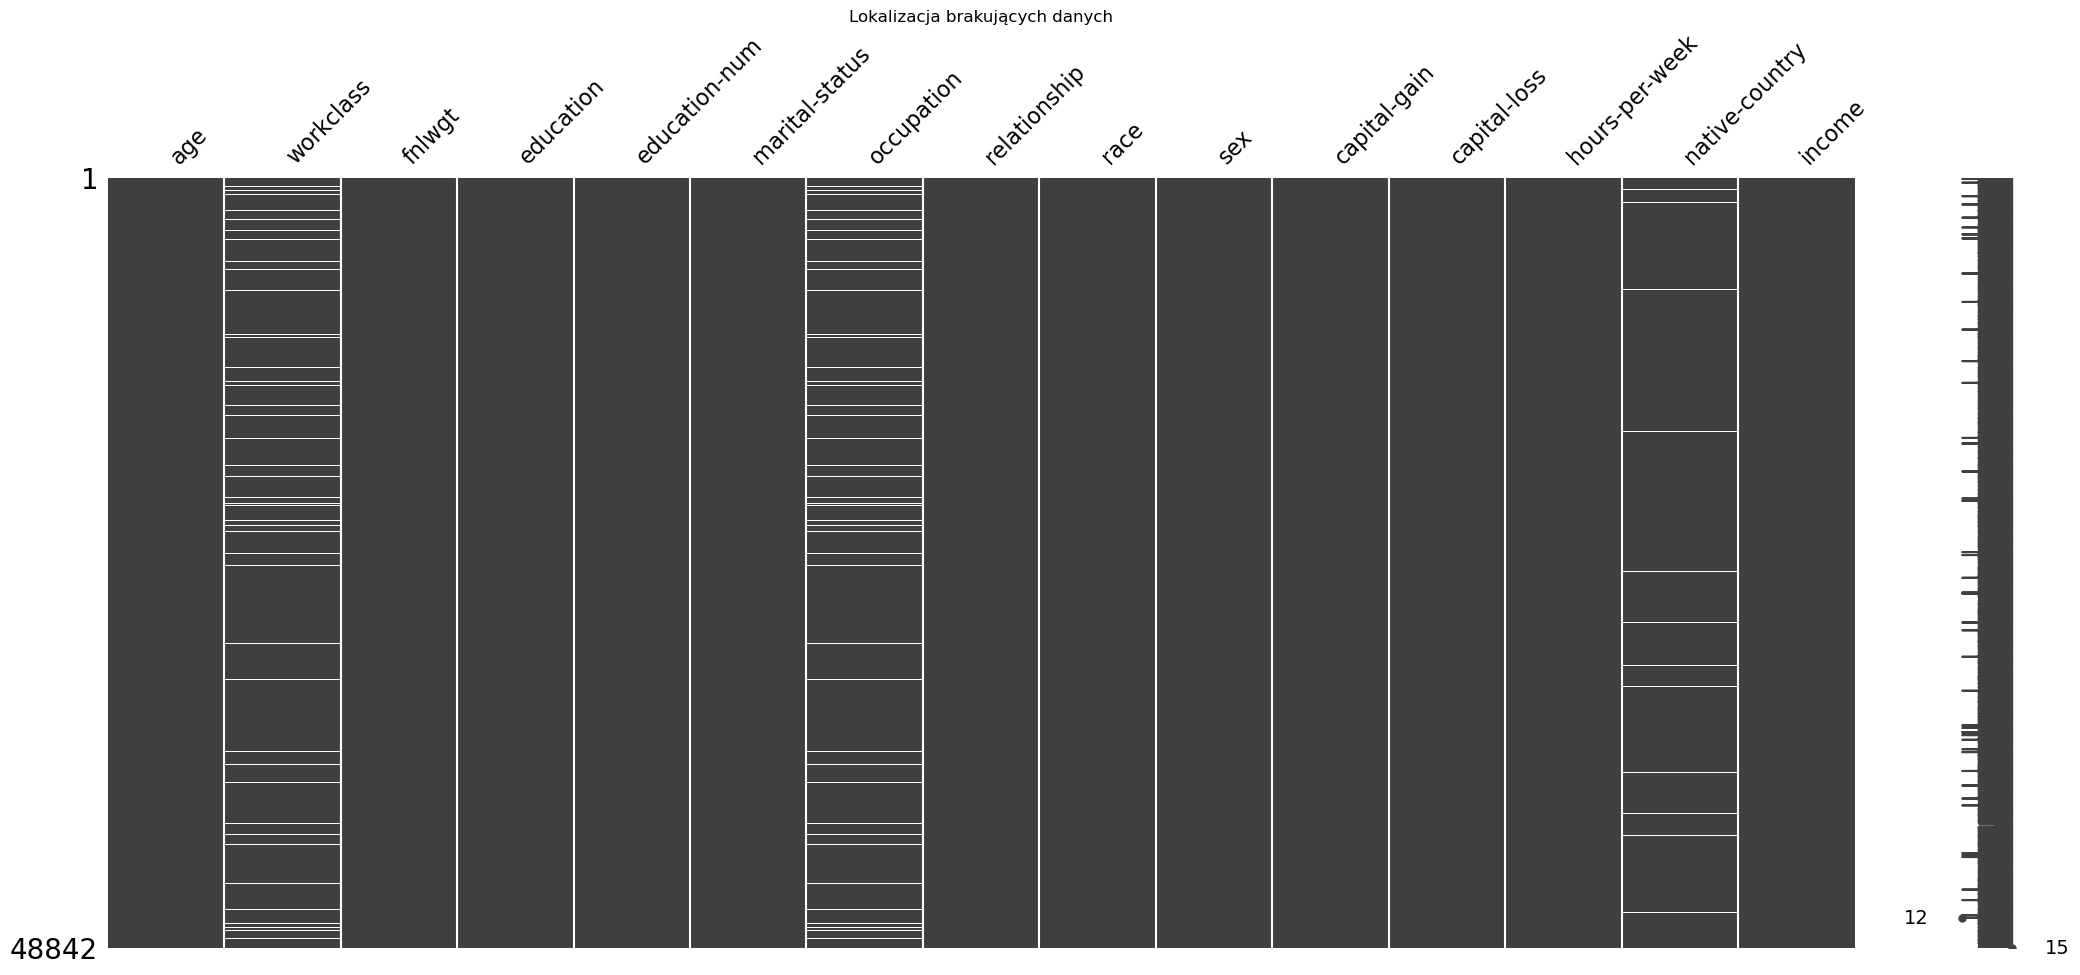

In [12]:
# Wizualizacja braków danych 
plt.figure(figsize=(10, 6))
msno.matrix(df)
plt.title("Lokalizacja brakujących danych")
plt.show()

In [13]:
# Tabela z procentem braków
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_df = pd.concat([null_counts, null_percent], axis=1, keys=['Liczba NaN', '%'])
print(null_df[null_df['Liczba NaN'] > 0])

                Liczba NaN         %
workclass             2799  5.730724
occupation            2809  5.751198
native-country         857  1.754637


### IMPUTACJA BRAKÓW DANYCH DLA ZMIENNYCH WORKCLASS, OCCUPATION, NATIVE-COUNTRY

In [14]:
# Braki w workclass występują razem z brakami w occupation, więc tworzona jest z nich nowa kategoria
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')

In [15]:
# native-country zostaje zastąpione najczęsciej pojawiającą się wartością
top_country = df['native-country'].mode()[0]
df['native-country'] = df['native-country'].fillna(top_country)

In [16]:
# OK
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Znaleziono {len(cat_cols)} zmiennych kategorycznych:\n")

for col in cat_cols:
    unique_values = df[col].unique()
    print(f"--- Kolumna: {col} ---")
    print(f"Liczba kategorii: {len(unique_values)}")
    print(f"Wartości: {unique_values}")
    print("-" * 30)

Znaleziono 9 zmiennych kategorycznych:

--- Kolumna: workclass ---
Liczba kategorii: 9
Wartości: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Unknown' 'Self-emp-inc' 'Without-pay' 'Never-worked']
------------------------------
--- Kolumna: education ---
Liczba kategorii: 16
Wartości: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
------------------------------
--- Kolumna: marital-status ---
Liczba kategorii: 7
Wartości: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
------------------------------
--- Kolumna: occupation ---
Liczba kategorii: 15
Wartości: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Unknown'
 'Protective-serv' 'Armed

In [17]:
# OK  - nie ma braków danych po modyfikacjach
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_df = pd.concat([null_counts, null_percent], axis=1, keys=['Liczba NaN', '%'])
print(null_df[null_df['Liczba NaN'] > 0])

Empty DataFrame
Columns: [Liczba NaN, %]
Index: []


In [18]:
# Usunięcie kolumny fnlwgt
df.drop('fnlwgt', axis=1, inplace=True)

In [19]:
# Usunięcie kolumny education-num, ponieważ zawiera to samo co education tylko w postaci liczb całkowitych
df.drop('education-num', axis=1, inplace=True)

### SPRAWDZENIE OUTLIERÓW

In [20]:
# Pobieranie tylko kolumn numerycznych
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Kolumny do sprawdzenia: {list(numeric_cols)}")

Kolumny do sprawdzenia: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']


In [21]:
# Obliczenie liczby outlierów metodą IQR
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'count': len(outliers),
        'percent': (len(outliers) / len(df)) * 100
    }

print("\n--- Podsumowanie wartości odstających (IQR) ---")
for col, stats in outlier_summary.items():
    print(f"{col}: {stats['count']} outlierów ({stats['percent']:.2f}%)")



--- Podsumowanie wartości odstających (IQR) ---
age: 216 outlierów (0.44%)
capital-gain: 4035 outlierów (8.26%)
capital-loss: 2282 outlierów (4.67%)
hours-per-week: 13496 outlierów (27.63%)


#### Outliery mieszczą się w rozsądnym przedziale, dlatego nie zdecydowano się na ich zmianę

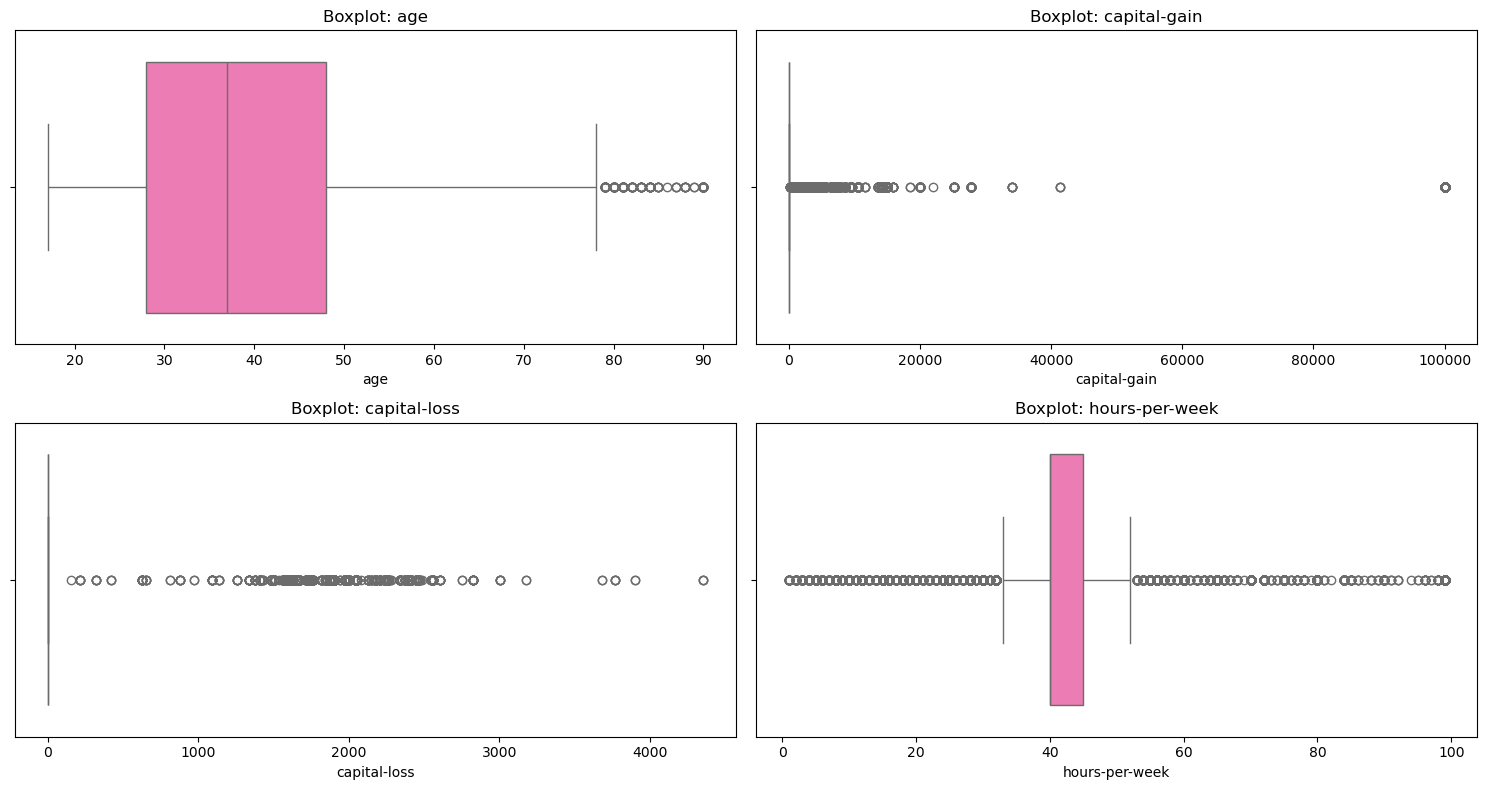

In [22]:
# Wizualizacja - wykresy pudełkowe dla wszystkich zmiennych numerycznych
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i)
    sns.boxplot(x=df[col], color="#ff69b4")
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


### KODOWANIE TYPU ONE-HOT

In [23]:
df_final = pd.get_dummies(df, drop_first=True)

# 3. Graficzna i opisowa analiza eksploracyjna (EDA), m.in. graficzna prezentacja zależności pomiędzy wybraną zmienną celu i zmiennymi niezależnymi, wykonanie i opisanie wyników segmentacji (klastrowania) rekordów, itp.

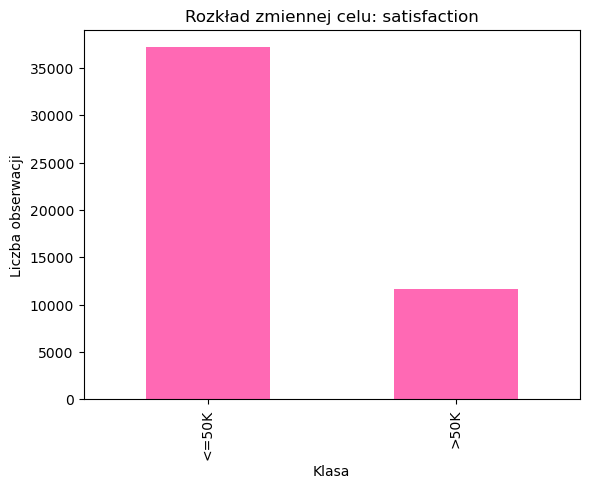

In [24]:
#rozkład zmiennej celu
#Zmienna jest niezbalansowana

df["income"].value_counts().plot(
    kind="bar",
    color="#ff69b4" 
)

plt.title("Rozkład zmiennej celu: satisfaction")
plt.ylabel("Liczba obserwacji")
plt.xlabel("Klasa")
plt.show()

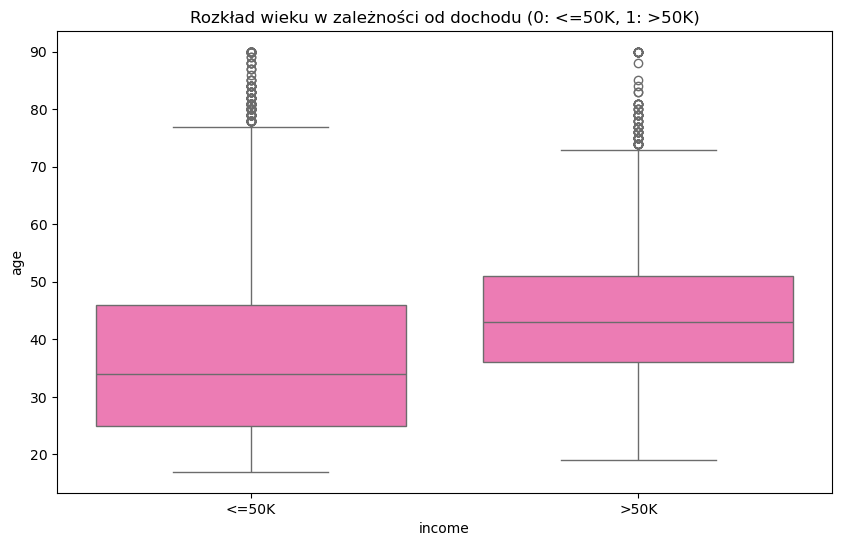

In [25]:
# Wykres zależności: Wiek vs Dochód
plt.figure(figsize=(10, 6))
sns.boxplot(x='income', y='age', data=df,     color="#ff69b4")
plt.title('Rozkład wieku w zależności od dochodu (0: <=50K, 1: >50K)')
plt.show()

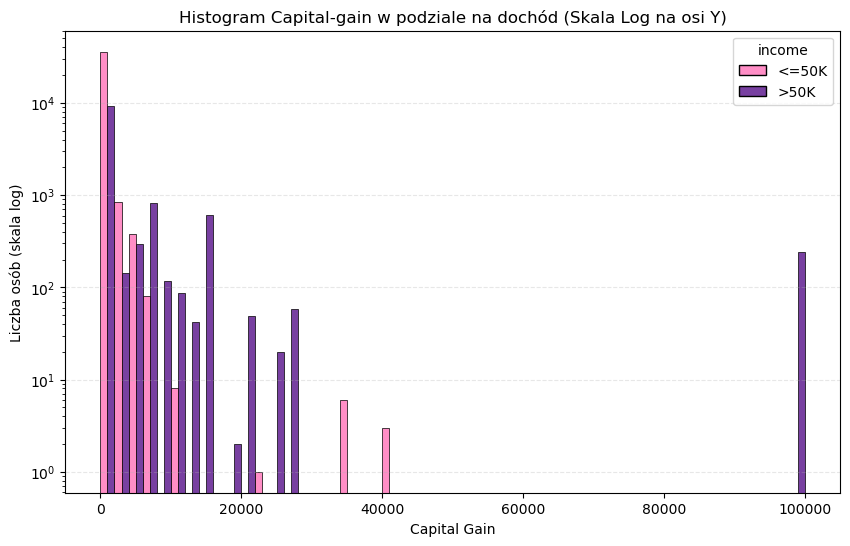

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='capital-gain', hue='income', 
             bins=50,             # Liczba słupków
             palette=['#ff69b4', '#4b0082'],     # Kolory
             multiple="dodge")    # Słupki obok siebie zamiast na sobie

# Skala logarytmiczna na osi Y pozwala zobaczyć rzadkie wysokie wartości
plt.yscale('log')

plt.title('Histogram Capital-gain w podziale na dochód (Skala Log na osi Y)')
plt.xlabel('Capital Gain')
plt.ylabel('Liczba osób (skala log)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

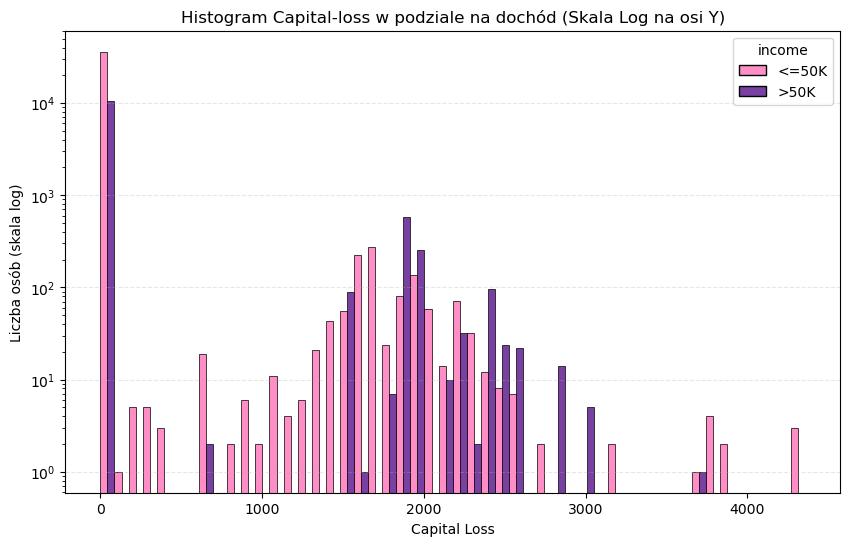

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='capital-loss', hue='income', 
             bins=50,             # Liczba słupków
             palette=['#ff69b4', '#4b0082'],     # Kolory
             multiple="dodge")    # Słupki obok siebie zamiast na sobie

plt.yscale('log')

plt.title('Histogram Capital-loss w podziale na dochód (Skala Log na osi Y)')
plt.xlabel('Capital Loss')
plt.ylabel('Liczba osób (skala log)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

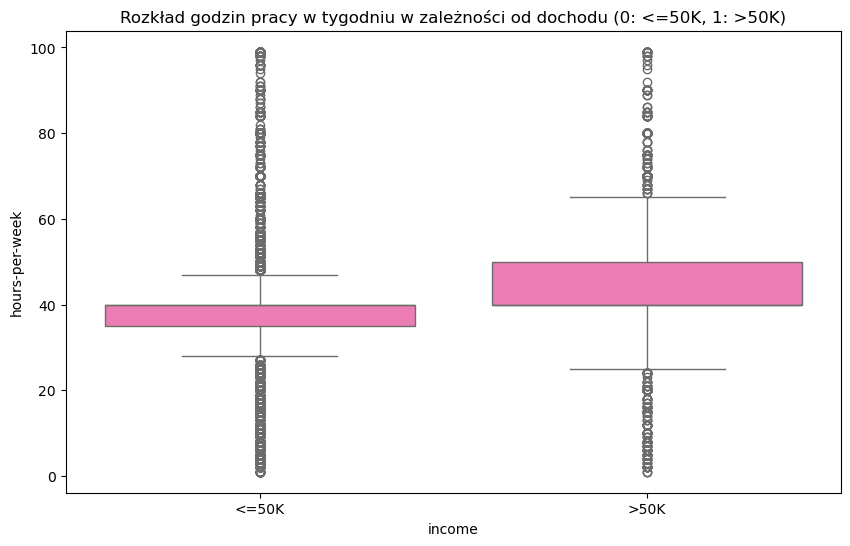

In [28]:
# Wykres zależności: Wiek vs Dochód
plt.figure(figsize=(10, 6))
sns.boxplot(x='income', y='hours-per-week', data=df,     color="#ff69b4")
plt.title('Rozkład godzin pracy w tygodniu w zależności od dochodu (0: <=50K, 1: >50K)')
plt.show()

In [29]:
def plot_percentage_distribution(df, column, target='income'):
    """
    Tworzy skumulowany wykres słupkowy pokazujący procentowy udział 
    kategorii celu (np. dochodu) wewnątrz danej zmiennej.
    """
    # 1. Tworzenie tabeli przestawnej z procentami
    cross_tab = pd.crosstab(df[column], df[target], normalize='index') * 100
    
    # 2. Sortowanie według udziału osób zarabiających >50K
    higher_income_col = cross_tab.columns[1] 
    cross_tab = cross_tab.sort_values(by=higher_income_col, ascending=True)
    
    # 3. Rysowanie wykresu
    ax = cross_tab.plot(kind='barh', 
                        stacked=True, 
                        figsize=(12, len(cross_tab) * 0.5 + 2), # Dynamiczna wysokość
                        color=['#ff69b4', '#4b0082'], 
                        edgecolor='white')
    
    # 4. Dodawanie etykiet procentowych na słupkach
    for p in ax.patches:
        width = p.get_width()
        if width > 5:  # Wyświetlaj tekst tylko jeśli segment jest widoczny
            x = p.get_x() + width / 2
            y = p.get_y() + p.get_height() / 2
            ax.annotate(f'{width:.1f}%', 
                        (x, y), 
                        ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=10)

    # Estetyka
    plt.title(f'Udział procentowy: {target} vs {column}', fontsize=14, pad=20)
    plt.xlabel('Procent [%]')
    plt.ylabel(column)
    plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- PRZYKŁADY UŻYCIA ---
# plot_percentage_distribution(df, 'workclass')
# plot_percentage_distribution(df, 'education')
# plot_percentage_distribution(df, 'marital-status')...

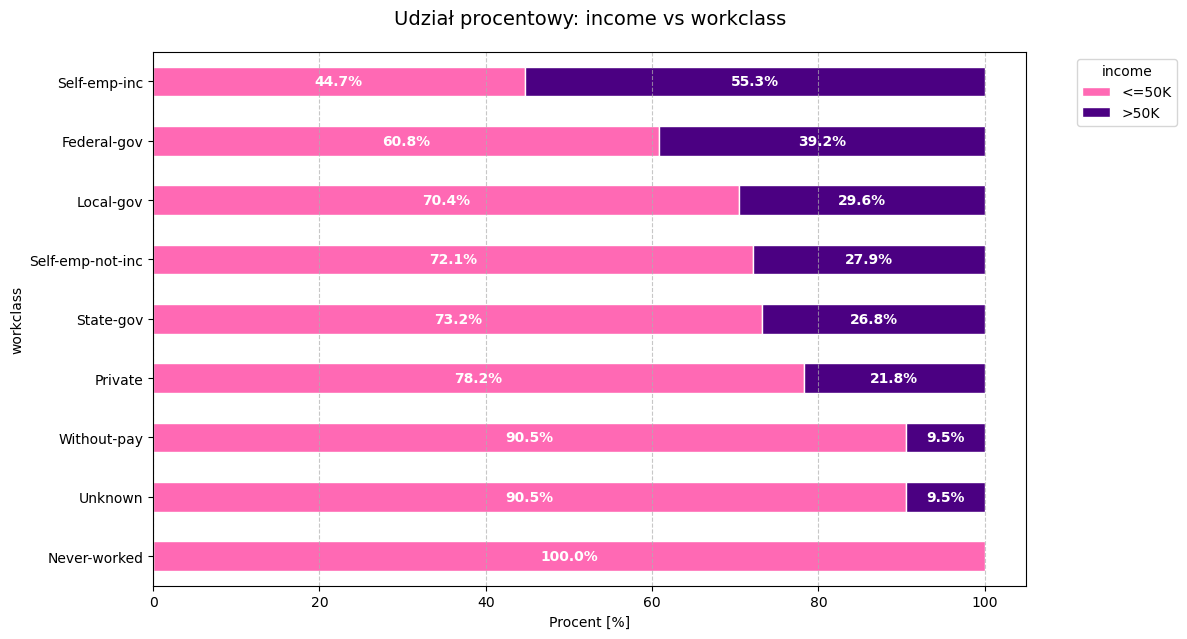

In [30]:
plot_percentage_distribution(df, 'workclass')

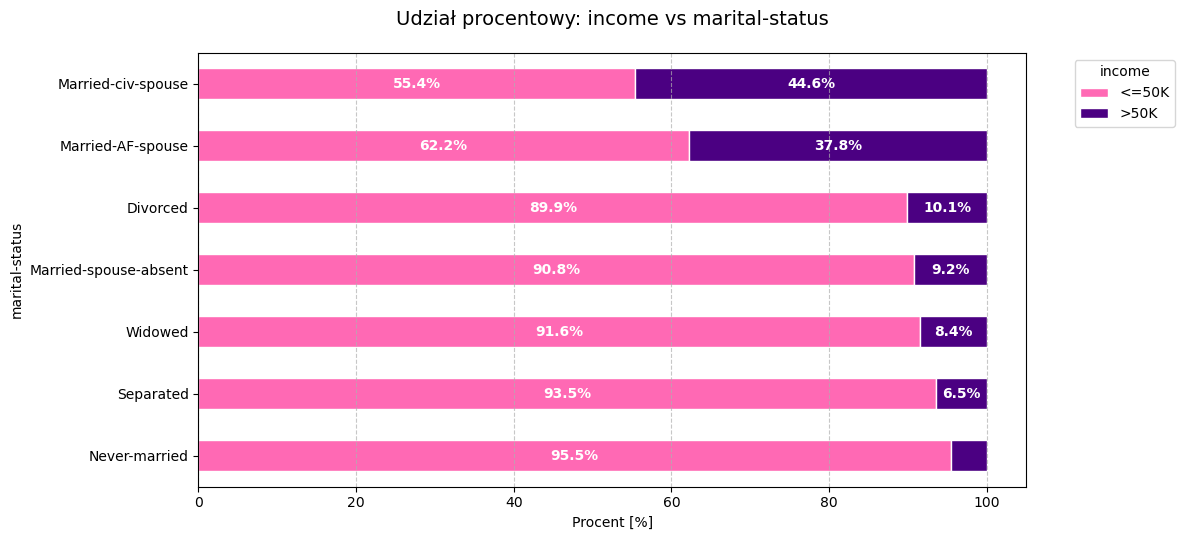

In [31]:
plot_percentage_distribution(df, 'marital-status')

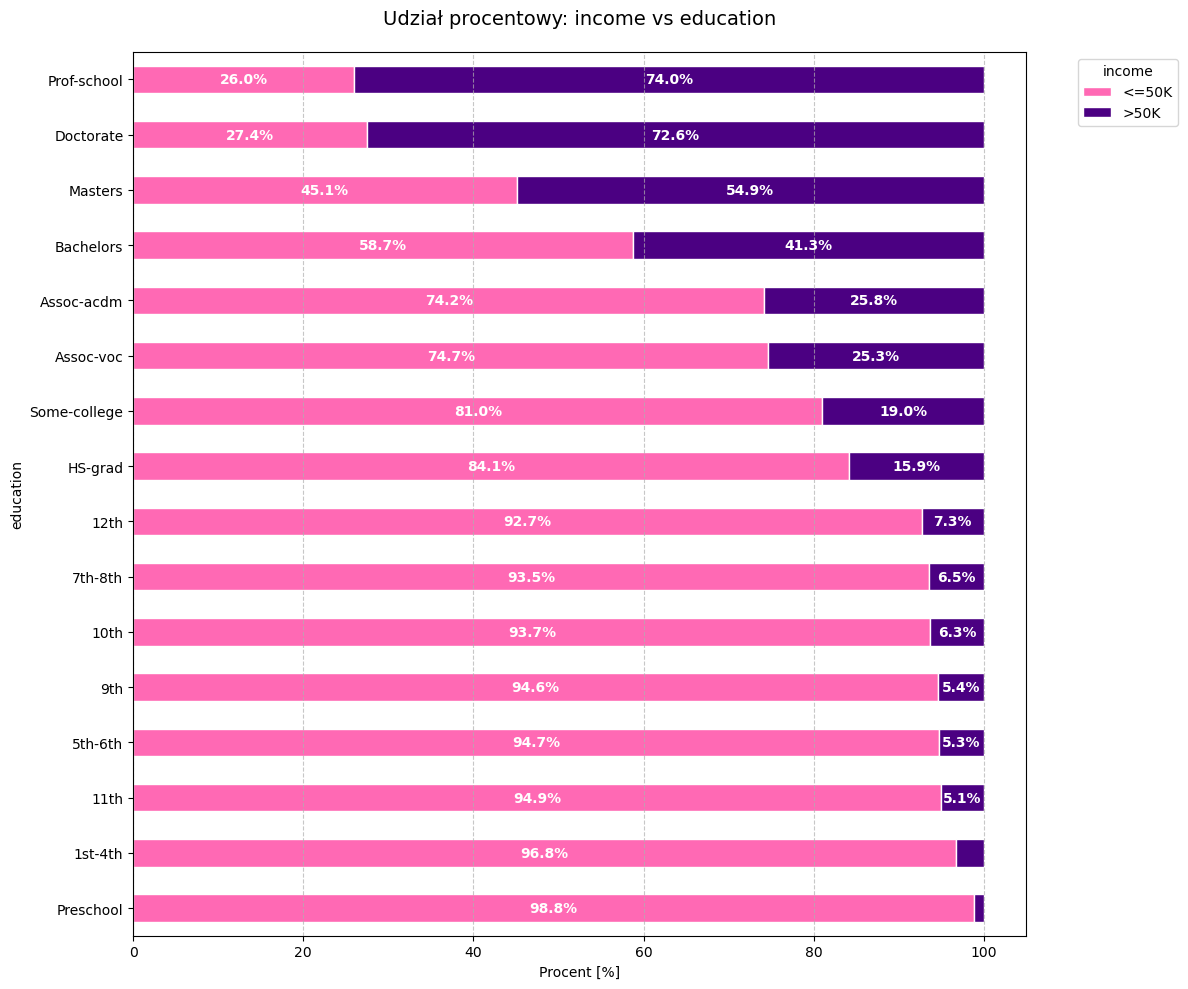

In [32]:
plot_percentage_distribution(df, 'education')

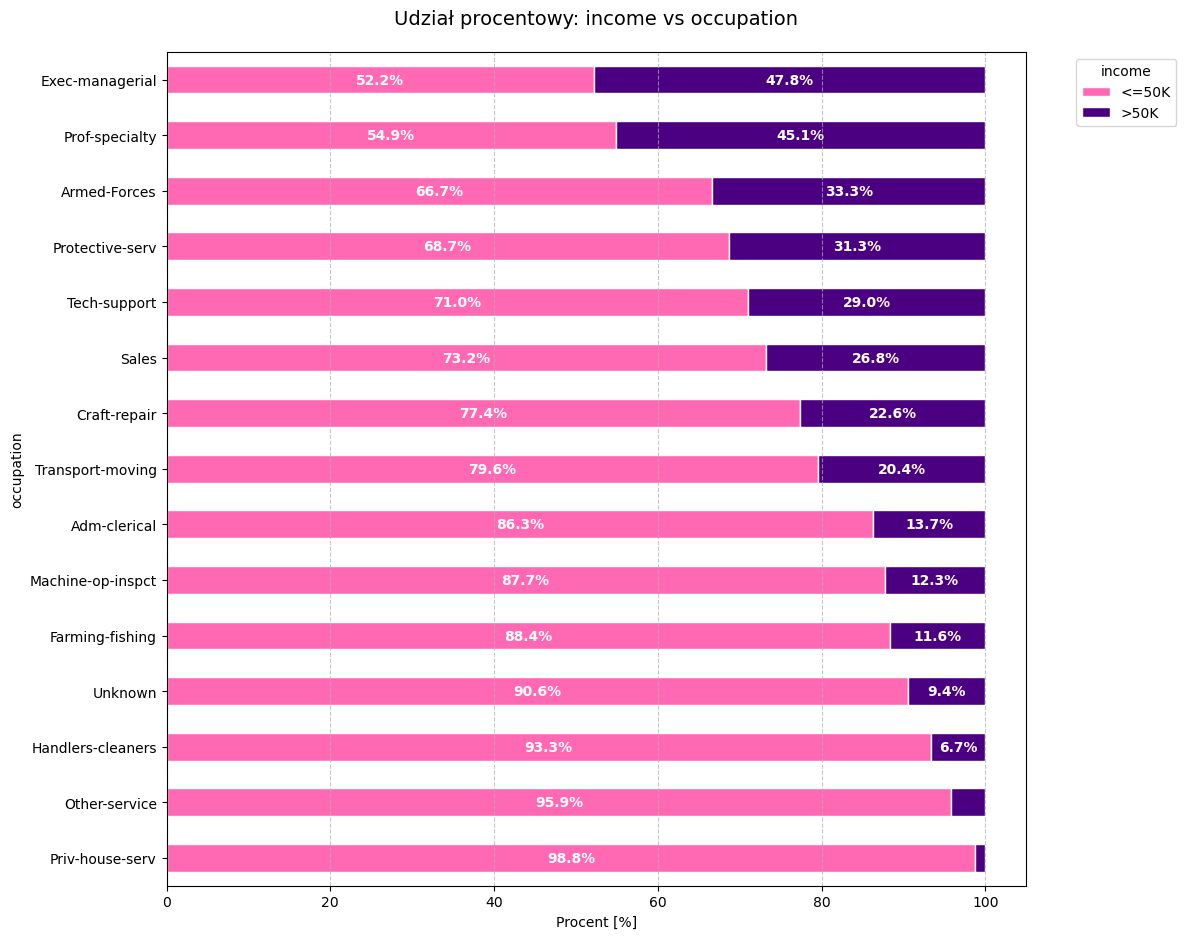

In [33]:
plot_percentage_distribution(df, 'occupation')

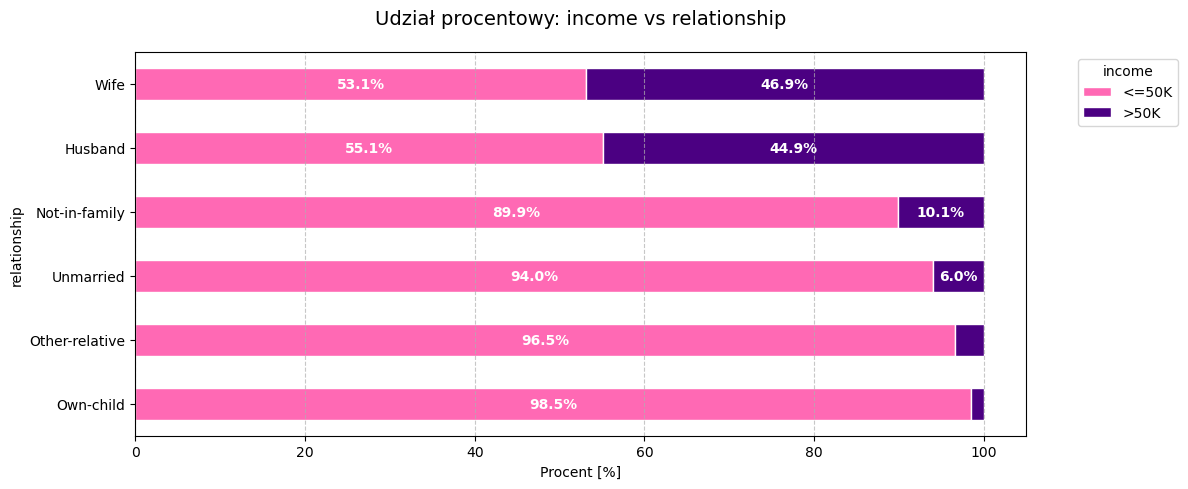

In [34]:
plot_percentage_distribution(df, 'relationship')

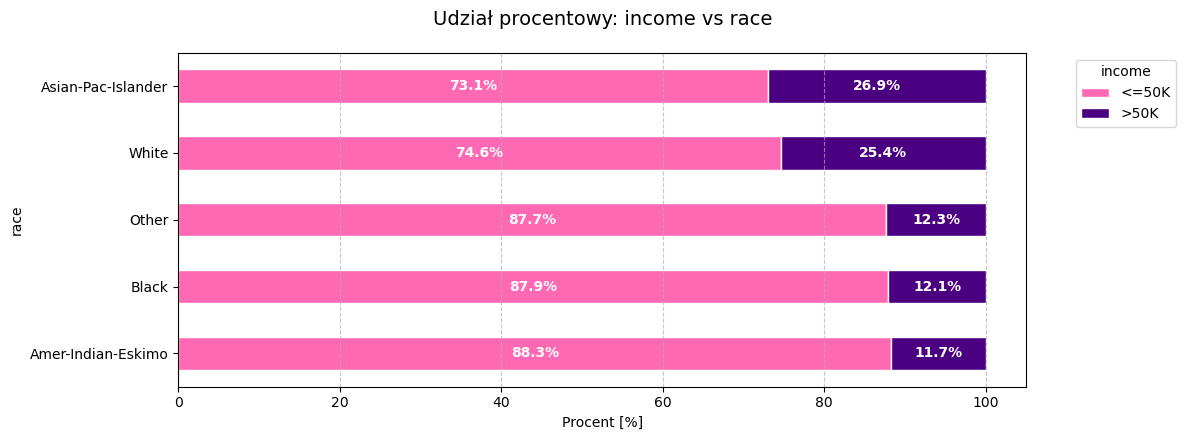

In [35]:
plot_percentage_distribution(df, 'race')

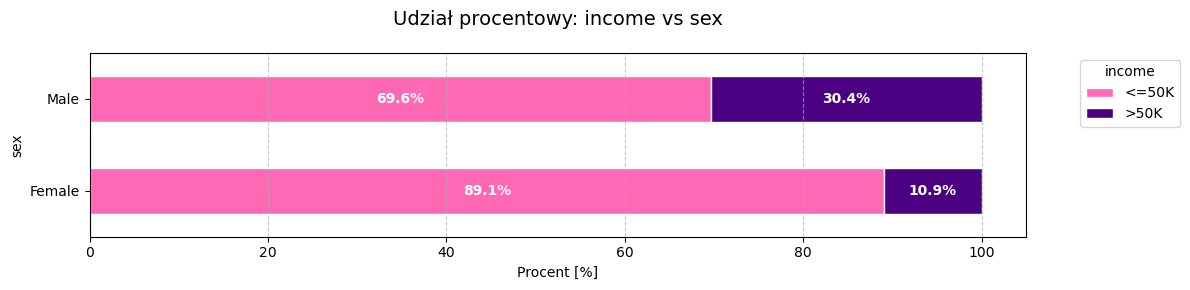

In [36]:
plot_percentage_distribution(df, 'sex')

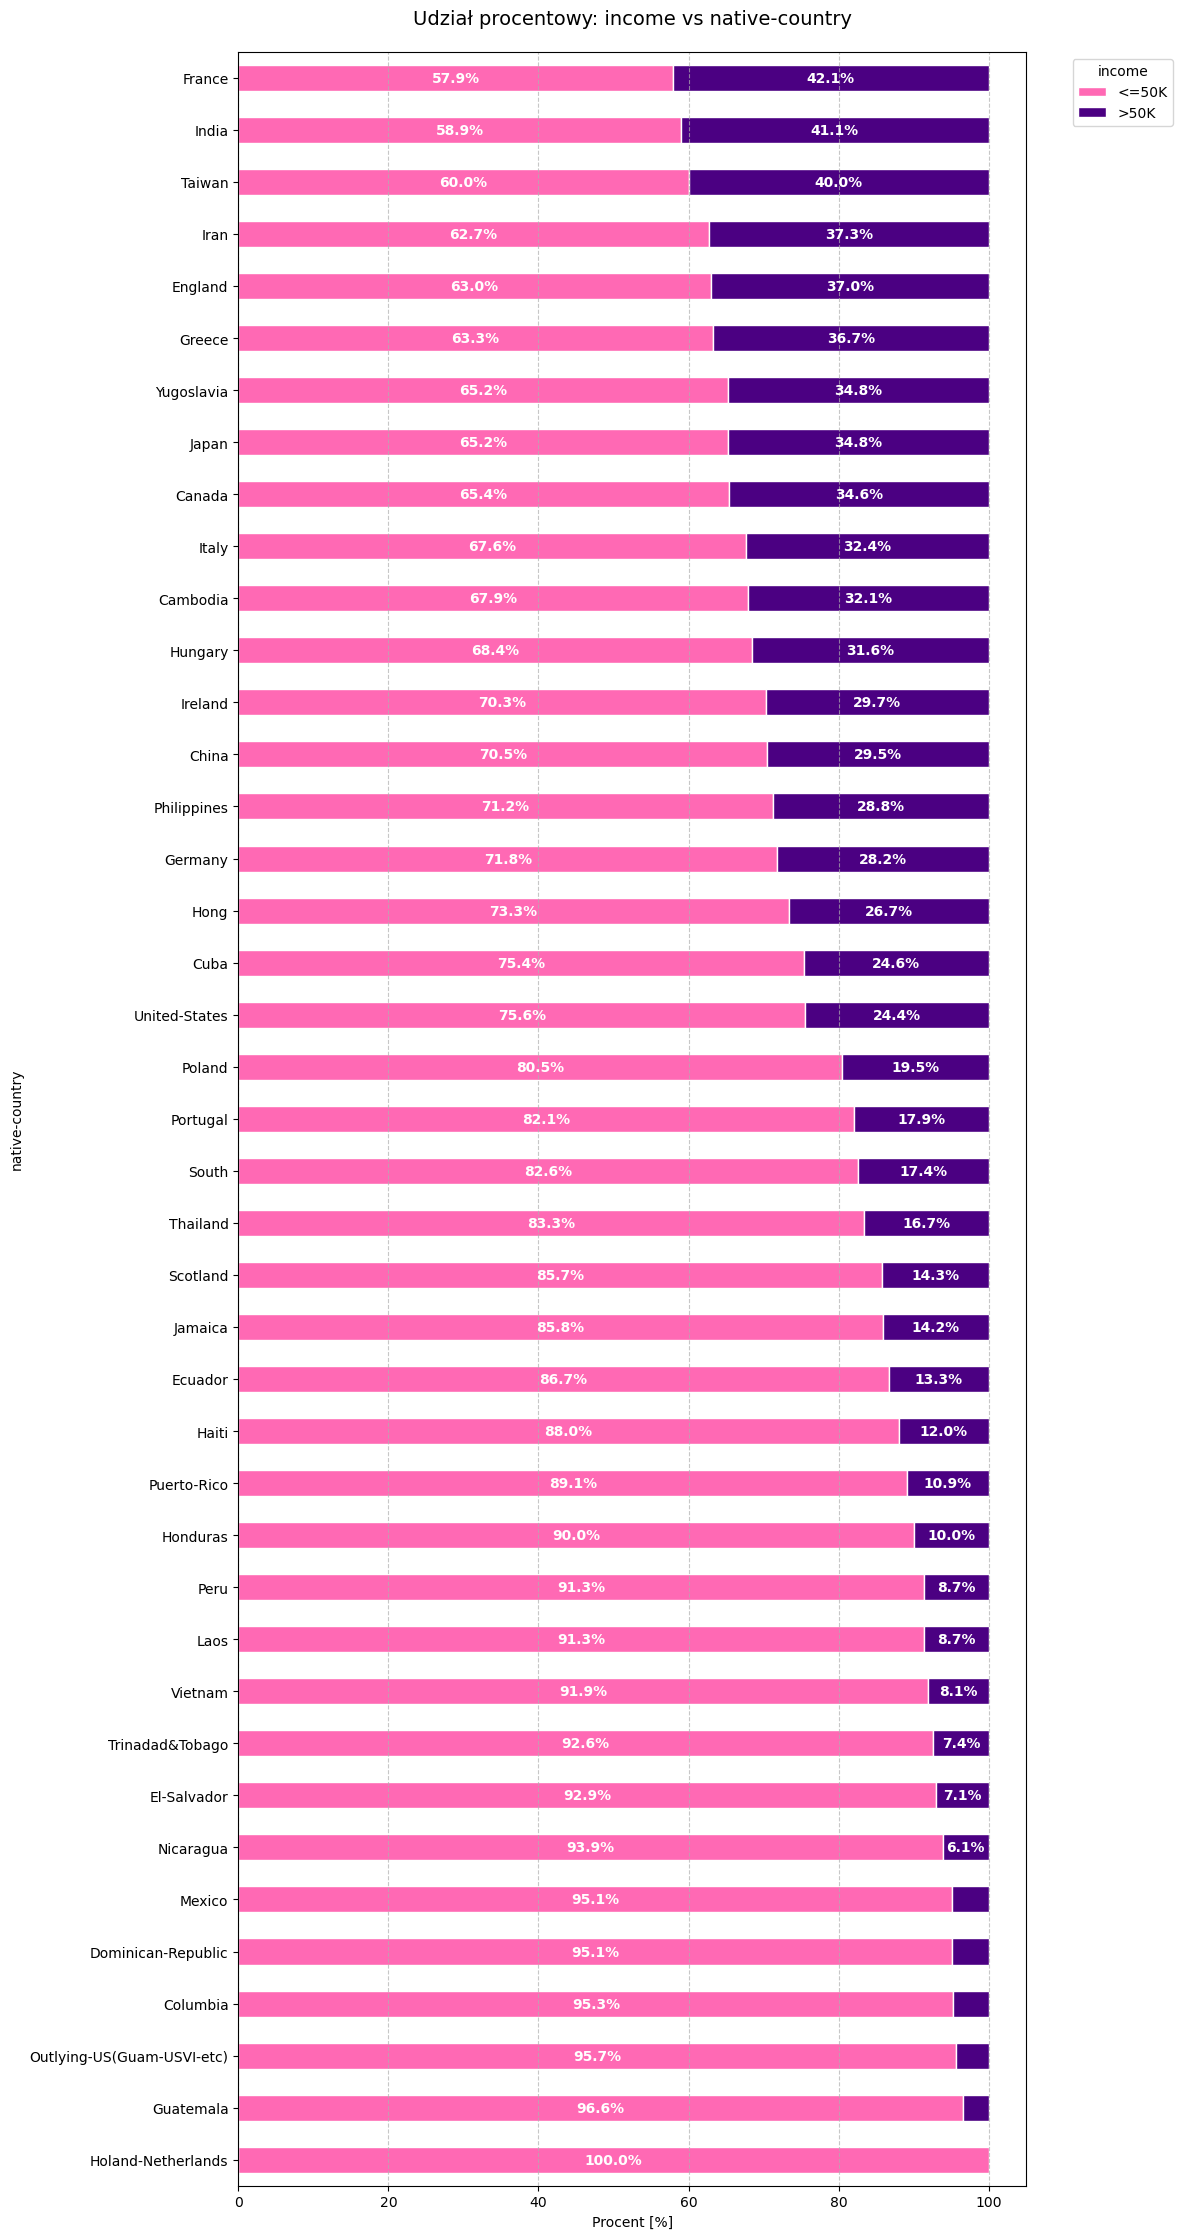

In [37]:
plot_percentage_distribution(df, 'native-country')

### GRUPOWANIE ZMIENNYCH METODĄ K-MEANS

In [38]:
# Standaryzacja zmiennych numerycznych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

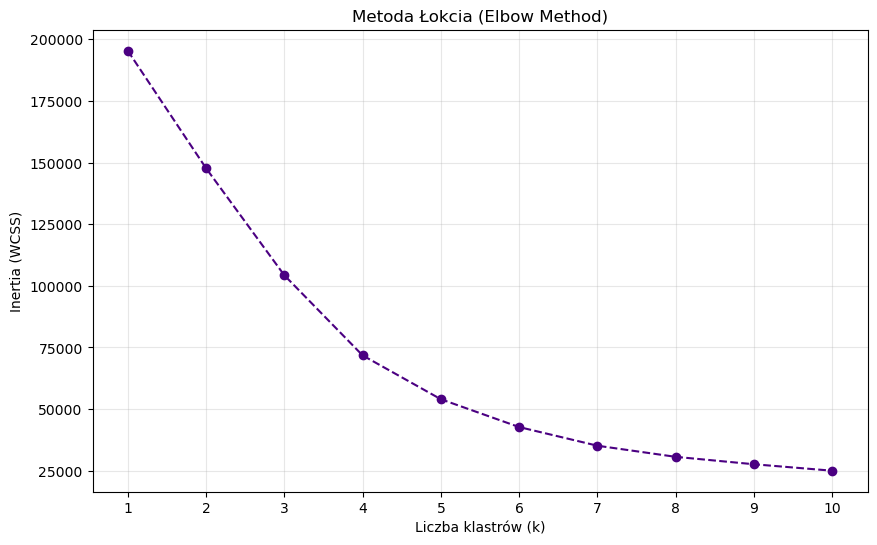

In [39]:
# 1. Obliczanie inertia dla różnych k
# Wydaje się, że k=3 lub k=4 będzie optymalne
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 2. Wizualizacja
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='#4b0082')

plt.title('Metoda Łokcia (Elbow Method)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.show()

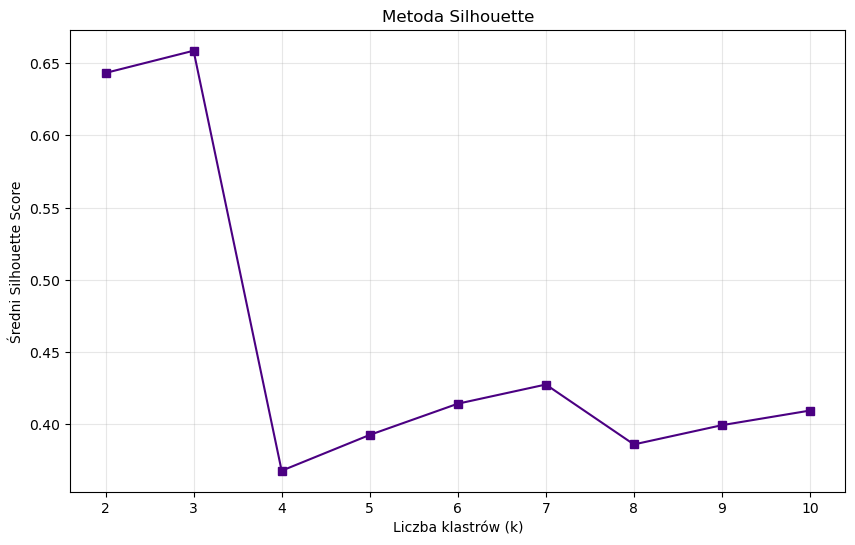

In [40]:
# Metoda Silhouette wyraźnie pokazuje, że najbardziej optymalna liczba klastrów wynosi 2 lub 3. 
silhouette_avg = []
k_range = range(2, 11) # Zaczęto od 2, bo nie da się policzyć Silhouette dla 1 klastra

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Średni wynik Silhouette dla całego zbioru
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

# Wizualizacja
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_avg, marker='s', linestyle='-', color='#4b0082')

plt.title('Metoda Silhouette')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Średni Silhouette Score')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.show()

In [41]:
# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [42]:
# Obliczenie średnich dla zmiennych numerycznych w każdym klastrze
cluster_summary = df.groupby('cluster')[numeric_cols].mean()

# Dodano liczebność każdego klastra, aby wiedzieć, jak są duże
cluster_summary['count'] = df['cluster'].value_counts()

display(cluster_summary)

,age,capital-gain,capital-loss,hours-per-week,count
cluster,,,,,
0,28.655975,258.933129,0.408440,37.999501,26065
1,50.976727,2237.437509,0.708749,43.178782,20539
2,41.778820,0.000000,1898.384718,43.344057,2238


Wyniki grupowaie k-means można przedstawić następująco:
- cluster 0: młodzi pracownicy - osoby najmłodsze, które mają niskie zyski kapitałowe, najniższe dochody i pracują najmniej
- cluster 1: doświadczeni inwestorzy - osoby najstarsze, najwięcej pracują, i mają najwyższe zyski kapitału
- cluster 2: inwestorzy wysokiego ryzyka - osoby najbardziej majętne (51% zarabia powyżej 50 000), pracujące najwięcej, które mimo wszystko mają straty kapitału

Procentowy udział dochodu w klastrach:


income,<=50K,>50K
cluster,,
0,87.393056,12.606944
1,64.657481,35.342519
2,48.972297,51.027703


<Figure size 1000x600 with 0 Axes>

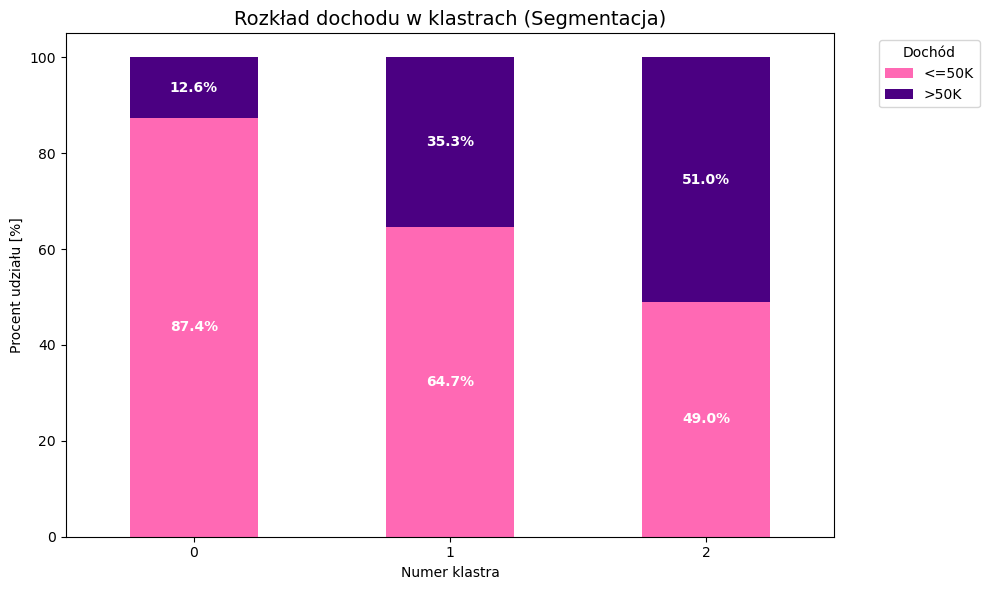

In [43]:
# 1. Obliczenie tabeli krzyżowej (Crosstab) z procentami
cluster_income_dist = pd.crosstab(df['cluster'], df['income'], normalize='index') * 100

# 2. Wyświetlenie tabeli z wynikami
print("Procentowy udział dochodu w klastrach:")
display(cluster_income_dist)

# 3. Wizualizacja
plt.figure(figsize=(10, 6))
# Jeśli income ma wartości 0 i 1, zmapujmy je dla czytelności legendy
plot_data = cluster_income_dist.copy()
if 0 in plot_data.columns:
    plot_data = plot_data.rename(columns={0: '<=50K', 1: '>50K'})

ax = plot_data.plot(kind='bar', stacked=True, color=['#ff69b4', '#4b0082'], figsize=(10,6))

# Dodanie etykiet procentowych na słupkach
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', color='white', fontweight='bold')

plt.title('Rozkład dochodu w klastrach (Segmentacja)', fontsize=14)
plt.xlabel('Numer klastra')
plt.ylabel('Procent udziału [%]')
plt.legend(title='Dochód', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Budowa modeli

**1. Model XGBoost**

In [44]:
X = df_final.drop(columns=["income_>50K"])
y = df_final["income_>50K"]

In [45]:
#Zamiana False/True na 0 i 1
bool_cols = df_final.select_dtypes(include="bool").columns

df_final[bool_cols] = df_final[bool_cols].astype(int)

df_final.head()

,age,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,39,2174,0,40,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
1,50,0,0,13,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,38,0,0,40,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,53,0,0,40,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,28,0,0,40,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
#XGBOOST
# Podział na zbiór treningowy i testowy (80/20)
# Użycie stratify=y, bo mamy niezbalansowane klasy (76/24)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Definicja modelu i parametrów (Tuning)
xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 6],           # Głębokość drzewa
    'learning_rate': [0.01, 0.1],     # Tempo uczenia
    'n_estimators': [100, 200],       # Liczba drzew
    'subsample': [0.8]                # Procent danych do budowy każdego drzewa
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Najlepszy model
best_xgb = grid_search.best_estimator_

print("\n--- Najlepsze parametry ---")
print(grid_search.best_params_)

D:\anaconda_unpack\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:26:04] WARNING: C:\miniconda3\conda-bld\xgboost-split_1764761400759\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Najlepsze parametry ---
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}



--- Najlepsze parametry ---
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

--- Metryki modelu (Zbiór testowy) ---
Accuracy: 0.8780
Precision: 0.7969
Recall: 0.6578
F1-Score: 0.7207

--- Pełny Raport Klasyfikacji ---
              precision    recall  f1-score   support

       False       0.90      0.95      0.92      7431
        True       0.80      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



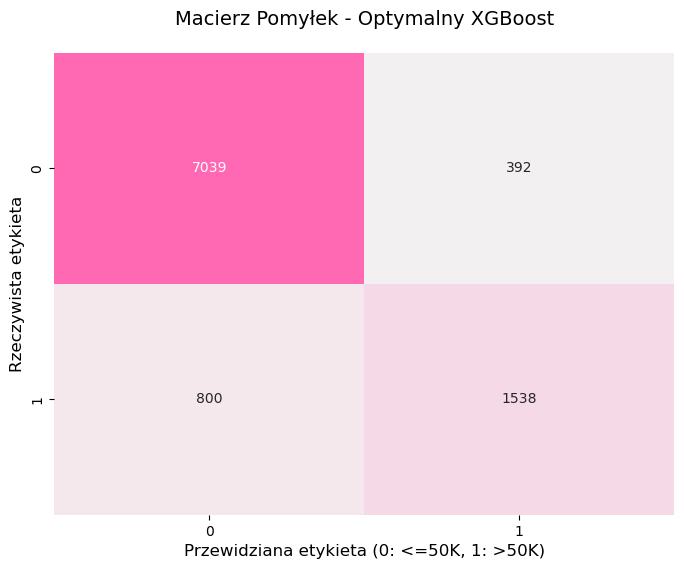

In [47]:
# Predykcja na zbiorze testowym
y_pred = best_xgb.predict(X_test)

# Obliczanie metryk
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

print("\n--- Najlepsze parametry ---")
print(grid_search.best_params_)

print("\n--- Metryki modelu (Zbiór testowy) ---")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

# Raport klasyfikacji (szczegóły dla klas 0 i 1)
print("\n--- Pełny Raport Klasyfikacji ---")
print(classification_report(y_test, y_pred))

# Wizualizacja: Macierz Pomyłek 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette("#ff69b4", as_cmap=True), cbar=False)
plt.title('Macierz Pomyłek - Optymalny XGBoost', fontsize=14, pad=20)
plt.xlabel('Przewidziana etykieta (0: <=50K, 1: >50K)', fontsize=12)
plt.ylabel('Rzeczywista etykieta', fontsize=12)
plt.show()

ROC-AUC: 0.9306036119697856


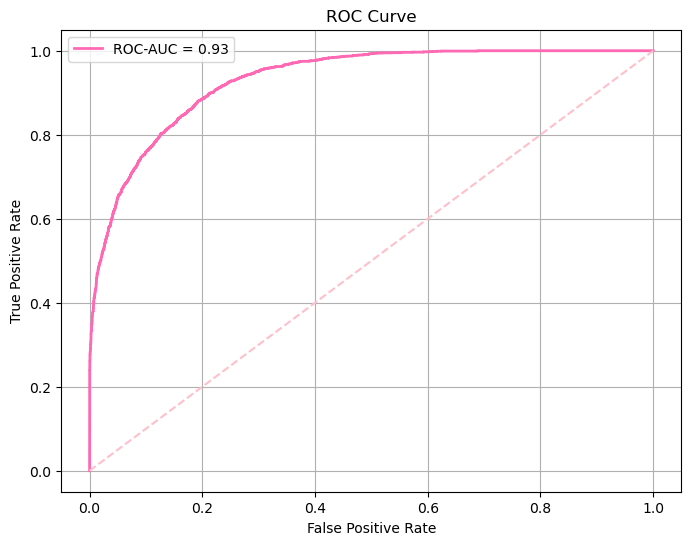

In [48]:
y_prob = grid_search.predict_proba(X_test)[:,1]  # prawdopodobieństwo dla klasy 1
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

# Wykres ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="#ff69b4", lw=2, label=f'ROC-AUC = {roc_auc:.2f}')  # linia ROC
plt.plot([0,1], [0,1], linestyle='--', color='pink')  # linia losowa
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


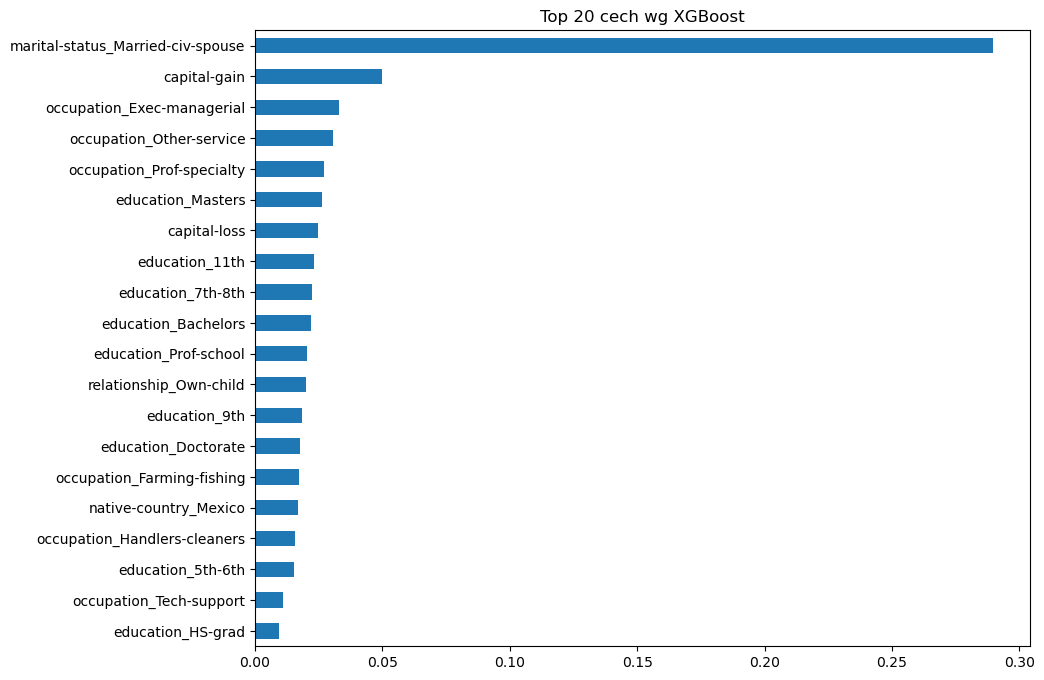

In [49]:
# feature importance

xgb_model = grid_search.best_estimator_ 

feature_importances = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

# Wykres top 20
feature_importances.head(20).plot(kind='barh', figsize=(10,8), )
plt.gca().invert_yaxis()
plt.title("Top 20 cech wg XGBoost")
plt.show()


### Model 2. Regresja logistyczna

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#definicja modelu bazowego
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

#definicja hiperparametrów
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

#GridSearchCV
grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

#Trening
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print("\n--- Najlepsze parametry ---")
print(grid_lr.best_params_)



--- Najlepsze parametry ---
{'C': 1}


D:\anaconda_unpack\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
#predykcja na zbiorze testowym
y_pred_lr = best_lr.predict(X_test)

metrics_lr = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr)
}

print("\n--- Metryki modelu (Zbiór testowy) ---")
for name, value in metrics_lr.items():
    print(f"{name}: {value:.4f}")

print("\n--- Pełny Raport Klasyfikacji ---")
print(classification_report(y_test, y_pred_lr))



--- Metryki modelu (Zbiór testowy) ---
Accuracy: 0.8063
Precision: 0.5649
Recall: 0.8302
F1-Score: 0.6723

--- Pełny Raport Klasyfikacji ---
              precision    recall  f1-score   support

       False       0.94      0.80      0.86      7431
        True       0.56      0.83      0.67      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.81      0.77      9769
weighted avg       0.85      0.81      0.82      9769



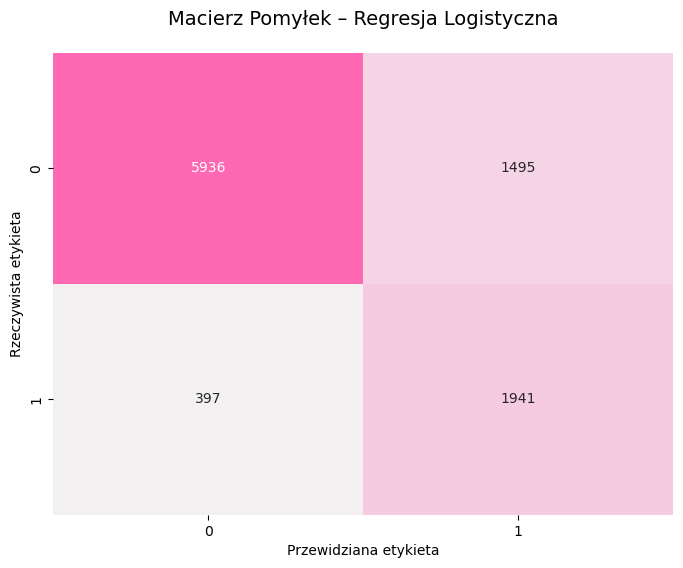

In [52]:
#macierz pomyłek
plt.figure(figsize=(8,6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap=sns.light_palette("#ff69b4", as_cmap=True),
    cbar=False
)
plt.title("Macierz Pomyłek – Regresja Logistyczna", fontsize=14, pad=20)
plt.xlabel("Przewidziana etykieta")
plt.ylabel("Rzeczywista etykieta")
plt.show()


ROC-AUC: 0.9039245460863266


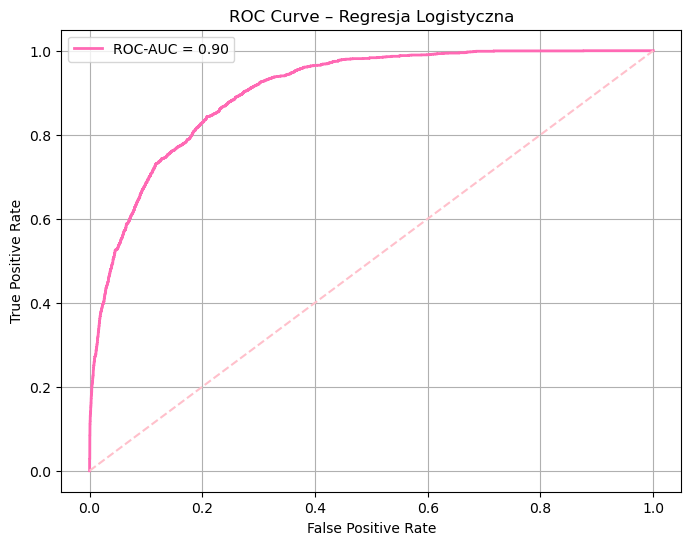

In [53]:
#ROC
y_prob_lr = grid_lr.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print("ROC-AUC:", roc_auc_lr)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, color="#ff69b4", lw=2, label=f'ROC-AUC = {roc_auc_lr:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='pink')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Regresja Logistyczna")
plt.legend()
plt.grid(True)
plt.show()


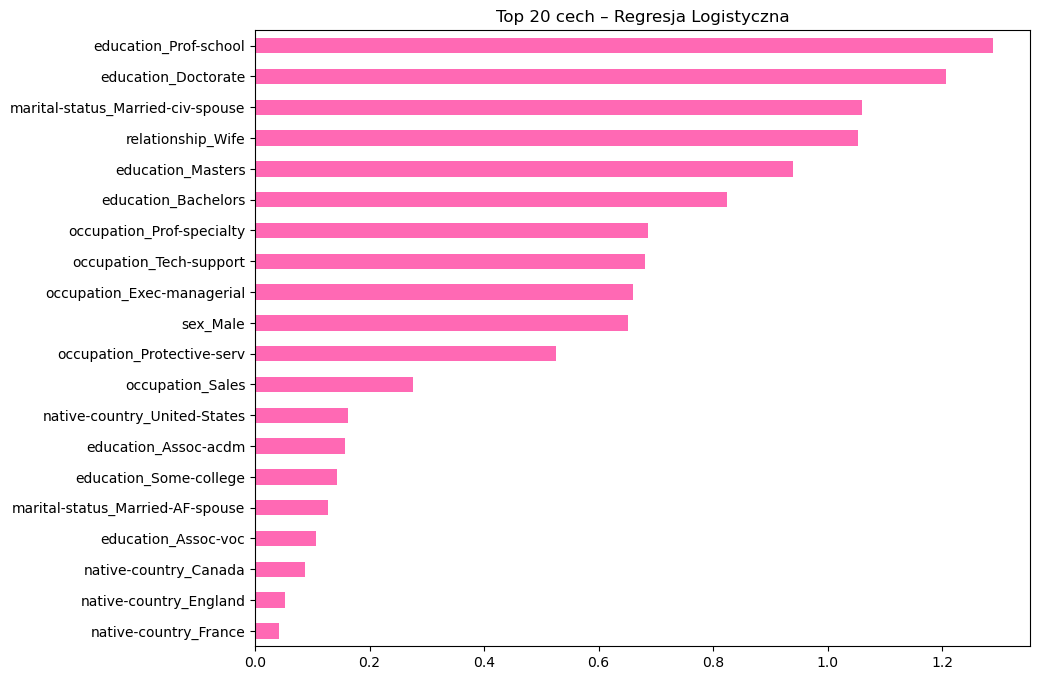

In [54]:
#współczynniki regresji
coefficients = pd.Series(
    best_lr.coef_[0],
    index=X.columns
).sort_values()

coefficients.tail(20).plot(kind='barh', figsize=(10,8), color="#ff69b4")
plt.title("Top 20 cech – Regresja Logistyczna")
plt.show()


### Model 3. Random Forest 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#implementacja lasu losowego
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

#hiperparametry
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

#GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

#Trenowanie
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("\n--- Najlepsze parametry ---")
print(grid_rf.best_params_)


In [ ]:
#predykcja
y_pred_rf = best_rf.predict(X_test)

metrics_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

print("\n--- Metryki modelu (Zbiór testowy) ---")
for name, value in metrics_rf.items():
    print(f"{name}: {value:.4f}")

print("\n--- Pełny Raport Klasyfikacji ---")
print(classification_report(y_test, y_pred_rf))


In [ ]:
#macierz pomyłek
plt.figure(figsize=(8,6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap=sns.light_palette("#ff69b4", as_cmap=True),
    cbar=False
)
plt.title("Macierz Pomyłek – Random Forest", fontsize=14, pad=20)
plt.xlabel("Przewidziana etykieta")
plt.ylabel("Rzeczywista etykieta")
plt.show()


In [ ]:
#ROC
y_prob_rf = grid_rf.predict_proba(X_test)[:,1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", roc_auc_rf)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color="#ff69b4", lw=2, label=f'ROC-AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle='--', color='pink')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#feature importance
feature_importances_rf = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importances_rf.head(20).plot(kind='barh', figsize=(10,8), color="#ff69b4")
plt.gca().invert_yaxis()
plt.title("Top 20 cech wg Random Forest")
plt.show()



# 5. Graficzna i opisowa ocena modeli oraz wybór modelu

#### W celu oceny jakości zbudowanych modeli klasyfikacyjnych przeprowadzono zarówno analizę ilościową, jak i graficzną. Wszystkie modele (Regresja logistyczna, Random Forest oraz XGBoost) oceniano na tym samym zbiorze testowym, który nie był wykorzystywany na etapie uczenia ani tuningu hiperparametrów.


Jako podstawowe miary jakości zastosowano metryki:
* Accuracy – określającą ogólny odsetek poprawnych predykcji,
* Precision – mierzącą trafność predykcji klasy pozytywnej,
* Recall – informującą o zdolności modelu do wykrywania obserwacji należących do klasy pozytywnej,
* F1-score – będącą harmoniczną średnią precision i recall, szczególnie istotną w przypadku niezbalansowanych danych.
* Krzywa ROC

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)
roc_auc_xgb = roc_auc_score(y_test, y_prob)

# ROC Regresja logistyczna
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

# ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Wspólny wykres
plt.figure(figsize=(9,7))

plt.plot(fpr_xgb, tpr_xgb, lw=2, color='pink', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_lr, tpr_lr, lw=2, color='hotpink', label=f'Regresja logistyczna (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, lw=2, color='deeppink', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Porównanie krzywych ROC dla modeli")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report_xgb = classification_report(y_test, y_pred, output_dict=True)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

df_xgb = pd.DataFrame(report_xgb).transpose()
df_lr = pd.DataFrame(report_lr).transpose()
df_rf = pd.DataFrame(report_rf).transpose()


In [ ]:
comparison_reports = pd.concat(
    [
        df_xgb[['precision', 'recall', 'f1-score']],
        df_lr[['precision', 'recall', 'f1-score']],
        df_rf[['precision', 'recall', 'f1-score']]
    ],
    axis=1,
    keys=['XGBoost', 'Regresja logistyczna', 'Random Forest']
)

comparison_reports


## XGBoost

Model XGBoost osiągnął najwyższą dokładność ogólną (accuracy = 0.88) oraz najwyższy wynik F1-score dla klasy pozytywnej (0.72). Precision dla klasy True wyniosło 0.80, a recall 0.66, co oznacza, że model skutecznie identyfikuje osoby o dochodzie powyżej 50K, zachowując jednocześnie dobrą równowagę pomiędzy liczbą fałszywych alarmów a liczbą pominiętych obserwacji.

Dodatkowo model uzyskał najwyższą wartość ROC-AUC = 0.93, co świadczy o bardzo dobrej zdolności do rozróżniania klas w szerokim zakresie progów decyzyjnych.

## Regresja logistyczna

Regresja logistyczna charakteryzuje się najwyższym recall dla klasy pozytywnej (0.83), co oznacza, że model rzadziej pomija osoby faktycznie należące do klasy True. Jednocześnie jednak osiąga ona najniższy precision (0.56), co prowadzi do większej liczby fałszywych pozytywnych predykcji.

Model ten uzyskał najniższą dokładność (accuracy = 0.81) oraz najniższy wynik F1-score dla klasy pozytywnej (0.67) spośród analizowanych algorytmów. Wartość ROC-AUC na poziomie 0.90 wskazuje na dobrą, lecz nie najlepszą separację klas.

## Random Forest

Random Forest stanowi kompromis pomiędzy dwoma pozostałymi modelami. Osiąga wysoki recall dla klasy pozytywnej (0.84) przy umiarkowanym precision (0.59), co daje F1-score = 0.69. Dokładność modelu wynosi 0.82, a wartość ROC-AUC 0.92, co plasuje go pomiędzy XGBoost a regresją logistyczną.
#

# 6. Podsumowanie wyników, dyskusja na temat napotkanych problemów, wyzwań i zastosowanych rozwiązań

### Podsumowanie wyników

Na podstawie przeprowadzonej analizy ilościowej i graficznej jako model końcowy wybrano XGBoost ze względu na:

* najwyższą wartość ROC-AUC (0.93),
* najlepszy F1-score dla klasy pozytywnej (0.72),
* najwyższą dokładność ogólną (0.88),
* dobrą równowagę pomiędzy precision i recall,

Model XGBoost zapewnia najlepszy kompromis pomiędzy skutecznością identyfikacji osób o dochodzie powyżej 50K a ograniczeniem liczby błędnych predykcji.

### Napotkane problemy, wyzwania i rozwiązania

#### 1. Dane:
W przypadku danych napotkane problemy obejmowały występowanie:
* wartości pustych dla zmiennych workclass, occupation, native-country
* wartości oznaczonych jako '?' dla zmiennych workclass, occupation, native-country
* wartości z kropką dla zmiennej income

#### Rozwiązanie:
* wartości ozaczone jako '?' zostały zamienione na nan

              df.replace('?', np.nan, inplace=True)
* dla wartości pustych zostały wykonane nastęujące czynności:
    * braki w workclass występują razem z brakami w occupation, więc tworzona jest z nich nowa kategoria
      
            df['workclass'] = df['workclass'].fillna('Unknown')
            df['occupation'] = df['occupation'].fillna('Unknown')
      
    * braki w native-country zostały zastąpione najczęsciej pojawiającą się wartością
      
            top_country = df['native-country'].mode()[0]
            df['native-country'] = df['native-country'].fillna(top_country)
      

* kropki przy wartościach zmiennej income zostały usunięte

              df['income'] = df['income'].str.rstrip('.')

#### 2. EDA
Podczas przeprowadzania analizy eksploracyjnej pojawiły się następujące trudności:

* dla zmiennych capital-gain oraz capital-loss większość obserwacji była zgromadzona w okolicach zera, więc wykresy były nieczytelne
* Metoda Silhouette była bardzo czasochłonna przy całym zbiorze danych (na analizowanym zbiorze trwało to ok 10-15 min)

#### Rozwiązanie/Obserwacje

* dla zmiennych capital-gain oraz capital-loss zastosowano skalę logarytmiczną na osi Y, aby zwiększyć czytelność wykresu
* w przypadku metody Silhouette liczbę klastrów należy wybierać roważnie, aby uniknąć długiego przetwarzania






#### 3. Modele

Długi czas trenowania modeli